# Sweep 1 — Belief (p0) vs blame

Two questions:
1. **Manipulation check** — does the model read each ordinal wording as the intended belief level? (`inferred_probability` should rise monotonically across levels.)
2. **The finding** — how does `blameworthiness` move across belief levels, and does it track the formal Shapley oracle (predicted: a peak near `somewhat_low`/`even`)?

Run a sweep first: `python -m sweeps.sweep1_p0` (from `experiment/`).

In [1]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

RESULTS = os.path.join('..', 'results')
LEVEL_ORDER = ['very_low','low','somewhat_low','even','somewhat_high','high','very_high']

paths = sorted(glob.glob(os.path.join(RESULTS, 'parsed_sweep1_p0_*.csv')))
assert paths, 'No parsed_sweep1_p0_*.csv in results/ — run the sweep first.'
df = pd.read_csv(paths[-1])
df = df[df['error'].isna()].copy()
df['level'] = pd.Categorical(df['level'], categories=LEVEL_ORDER, ordered=True)
df['level_rank'] = df['level'].cat.codes
print(f'Loaded {paths[-1]}  ({len(df)} successful rows, model={df["model"].iloc[0]})')
df.head()

Loaded ../results/parsed_sweep1_p0_gemini-2.0-flash-001_20260529_183626.csv  (312 successful rows, model=google/gemini-2.0-flash-001)


,run_id,sweep,scenario,model,level,phrasing_idx,rep,blameworthiness,inferred_probability,oracle_at_reference,oracle_at_inferred,error,level_rank
0,very_low-0-0,sweep1_p0,s01_health,google/gemini-2.0-flash-001,very_low,0,0,20.0,10.0,0.082319,0.082319,NaN,0
1,very_low-0-1,sweep1_p0,s01_health,google/gemini-2.0-flash-001,very_low,0,1,20.0,10.0,0.082319,0.082319,NaN,0
2,very_low-0-2,sweep1_p0,s01_health,google/gemini-2.0-flash-001,very_low,0,2,15.0,10.0,0.082319,0.082319,NaN,0
3,very_low-0-3,sweep1_p0,s01_health,google/gemini-2.0-flash-001,very_low,0,3,20.0,1.0,0.082319,0.051790,NaN,0
4,very_low-0-4,sweep1_p0,s01_health,google/gemini-2.0-flash-001,very_low,0,4,20.0,10.0,0.082319,0.082319,NaN,0


In [2]:
# Per-level aggregates with bootstrap 95% CIs
def boot_ci(x, n=2000, seed=0):
    x = np.asarray(x, float)
    rng = np.random.default_rng(seed)
    means = rng.choice(x, size=(n, len(x)), replace=True).mean(axis=1)
    return np.percentile(means, [2.5, 97.5])

agg = (df.groupby('level', observed=True)
         .agg(blame=('blameworthiness','mean'),
              inferred=('inferred_probability','mean'),
              oracle_ref=('oracle_at_reference','mean'),
              oracle_inf=('oracle_at_inferred','mean'),
              n=('blameworthiness','size'))
         .reindex(LEVEL_ORDER))
blame_ci = df.groupby('level', observed=True)['blameworthiness'].apply(boot_ci).reindex(LEVEL_ORDER)
inf_ci   = df.groupby('level', observed=True)['inferred_probability'].apply(boot_ci).reindex(LEVEL_ORDER)
agg

,blame,inferred,oracle_ref,oracle_inf,n
level,,,,,
very_low,17.777778,6.622222,0.082319,0.070723,45
low,25.111111,20.888889,0.108153,0.108584,45
somewhat_low,30.222222,33.088889,0.127956,0.123033,45
even,27.166667,47.071429,0.105836,0.107976,42
somewhat_high,29.800000,59.555556,0.072739,0.074211,45
high,24.555556,71.555556,0.012638,0.035359,45
very_high,19.444444,91.088889,0.001947,0.002932,45


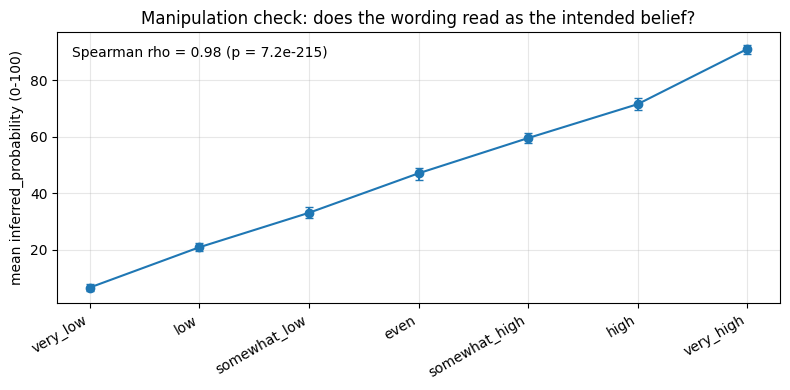

In [3]:
# 1) Manipulation check: inferred_probability vs intended ordinal level
x = np.arange(len(LEVEL_ORDER))
yerr = np.abs(np.vstack(inf_ci.values).T - agg['inferred'].values)
fig, ax = plt.subplots(figsize=(8,4))
ax.errorbar(x, agg['inferred'], yerr=yerr, marker='o', capsize=3)
ax.set_xticks(x); ax.set_xticklabels(LEVEL_ORDER, rotation=30, ha='right')
ax.set_ylabel('mean inferred_probability (0-100)')
ax.set_title('Manipulation check: does the wording read as the intended belief?')
ax.grid(alpha=0.3)
rho, p = spearmanr(df['level_rank'], df['inferred_probability'])
ax.text(0.02, 0.95, f'Spearman rho = {rho:.2f} (p = {p:.1e})', transform=ax.transAxes, va='top')
plt.tight_layout(); plt.show()

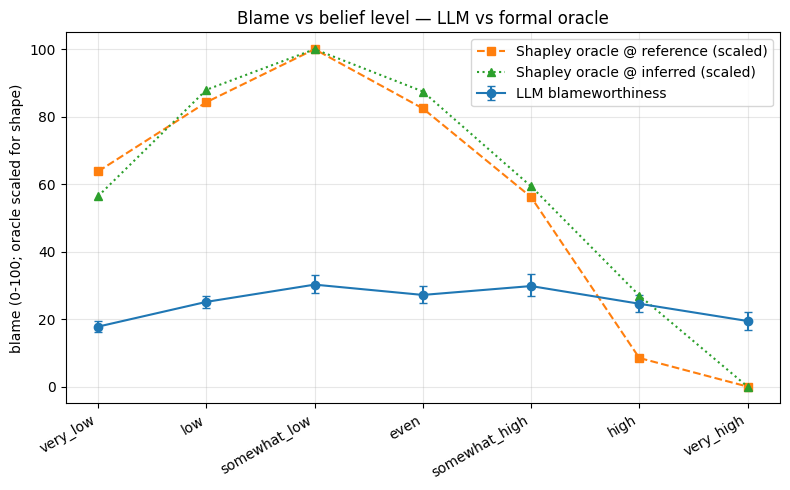

In [4]:
# 2) The finding: blame vs belief, with the Shapley oracle overlaid.
# Oracle is in absolute units (~0-0.1); min-max scale to 0-100 to compare SHAPE.
def scale01(s):
    s = np.asarray(s, float); lo, hi = np.nanmin(s), np.nanmax(s)
    return np.full_like(s, 50.0) if hi == lo else (s - lo) / (hi - lo) * 100

yerr = np.abs(np.vstack(blame_ci.values).T - agg['blame'].values)
fig, ax = plt.subplots(figsize=(8,5))
ax.errorbar(x, agg['blame'], yerr=yerr, marker='o', capsize=3, label='LLM blameworthiness')
ax.plot(x, scale01(agg['oracle_ref']), marker='s', ls='--', label='Shapley oracle @ reference (scaled)')
ax.plot(x, scale01(agg['oracle_inf']), marker='^', ls=':',  label='Shapley oracle @ inferred (scaled)')
ax.set_xticks(x); ax.set_xticklabels(LEVEL_ORDER, rotation=30, ha='right')
ax.set_ylabel('blame (0-100; oracle scaled for shape)')
ax.set_title('Blame vs belief level — LLM vs formal oracle')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [5]:
# Shape + rank agreement vs the oracle
r_ref, p_ref = spearmanr(df['level_rank'], df['blameworthiness'])
ord_ref = spearmanr(agg['blame'], agg['oracle_ref']).correlation
ord_inf = spearmanr(agg['blame'], agg['oracle_inf']).correlation
peak = agg['blame'].idxmax()
print(f'Blame vs level rank:           rho = {r_ref:+.2f} (p = {p_ref:.1e})')
print(f'Blame vs oracle @ reference:   rho = {ord_ref:+.2f}')
print(f'Blame vs oracle @ inferred:    rho = {ord_inf:+.2f}')
print(f'LLM blame peaks at level:      {peak}')
print('Theory predicts a peak around somewhat_low / even (non-monotonic).')

Blame vs level rank:           rho = +0.02 (p = 7.2e-01)
Blame vs oracle @ reference:   rho = +0.57
Blame vs oracle @ inferred:    rho = +0.75
LLM blame peaks at level:      somewhat_low
Theory predicts a peak around somewhat_low / even (non-monotonic).
